# Set Up

## Mount Google Drive

Ignore if not using Google Collab:

In [1]:
%%capture
from google.colab import drive

# mount google drive
drive.mount('/content/drive')
%cd /content/drive/My Drive
!git clone https://github.com/FranciscoLozCoding/cooling_with_code.git
%cd cooling_with_code
!git pull

## Import Libraries

In [2]:
%%capture
%pip install shap
%pip install stackstac
%pip install pystac-client
%pip install planetary-computer
%pip install odc-stac
%pip install rioxarray
%pip install geopy
%pip install geopandas
%pip install keras-tuner

In [3]:
# Supress Warnings
import warnings
warnings.filterwarnings('ignore')

#data science
import pandas as pd
import numpy as np
import shap
import pickle
from tensorflow.keras.models import load_model

#other
import os

#custom tools
from tools.environment import VALID_SPLIT, RANDOM_STATE, TARGET_VARIABLE, MixBuf_ResNet_SelectAttr
from tools.preprocess import apply_preprocessing_mixed_buffers, load_and_preprocess_data
from tools.explainer import Explainer
from tools.build_dataset import combine_buffer_datasets

## Load Model

Here we will load our best model.

In [4]:
# get model
model_file = 'models/mixed_buffers_ResNet/mixed_buffers_ResNet_model.keras'
if os.path.exists(model_file):
  resnet_model = load_model(model_file)

# scaler
scaler_file = 'models/mixed_buffers_ResNet/mixed_buffers_standard_scaler.pkl'
with open(scaler_file, 'rb') as f:
  scaler = pickle.load(f)

## Import Datasets

Here we will import the dataset used by our best model.

In [5]:
train_combined, test_combined = combine_buffer_datasets('data/train', 'data/test')
train_combined, test_combined = apply_preprocessing_mixed_buffers(train_combined, test_combined)
selected_feature_names = MixBuf_ResNet_SelectAttr

Loading training data: data/train/50m_buffer_dataset.csv
Loading test data: data/test/50m_buffer_test_dataset.csv
Loading training data: data/train/100m_buffer_dataset.csv
Loading test data: data/test/100m_buffer_test_dataset.csv
Loading training data: data/train/150m_buffer_dataset.csv
Loading test data: data/test/150m_buffer_test_dataset.csv
Loading training data: data/train/300m_buffer_dataset.csv
Loading test data: data/test/300m_buffer_test_dataset.csv

Final Training Dataset Shape: (11229, 77)
Final Test Dataset Shape: (1040, 78)

Final Processed Training Dataset Shape: (11229, 200)
Final Processed Testing Dataset Shape: (1040, 201)


## Make Predictions

Here we will make predictions using our best model. SHAP will need them.

In [6]:
# Remove lat and lon, for now will be combined with predicted UHI later for submission
lon = test_combined['Longitude'].values
lat = test_combined['Latitude'].values
test_dataset = test_combined.drop(columns=['Longitude', 'Latitude'])

#select features
test_dataset = test_dataset[selected_feature_names]

#scale
x_test = pd.DataFrame(scaler.transform(test_dataset),
                      columns=test_dataset.columns,
                      index=test_dataset.index).values

# Model prediction
y_pred = resnet_model.predict(x_test)

33/33 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step


# In-Depth SHAP Analysis

This notebook is dedicated to performing an in-depth [**SHAP analysis**](https://shap.readthedocs.io/en/latest/) on our optimal predictive model, the **Mixed Buffer ResNet**. Although this model exhibited a slightly lower R-squared score compared to alternatives, it demonstrated reduced signs of overfitting and was more computationally efficient, with a significantly smaller file size (44 MB). Further details about the **Mixed Buffer ResNet** model, including its training process and initial evaluations, can be found in our [11_mixed_buffers_ResNet notebook](/11_mixed_buffers_RestNet.ipynb). While the previous notebook included a preliminary SHAP analysis, the present notebook aims to substantially expand upon those findings. Specifically, this comprehensive SHAP analysis will elucidate feature importance rankings, clarify the relationships between individual features and model predictions, and provide explanations for individual prediction outcomes. This analysis is crucial to gaining deeper insights into the key drivers influencing the Urban Heat Island phenomenon.



In [7]:
# Initialize SHAP Explainer for keras model depending if shap_values were precomputed
shap_vals_file = 'data/test/mixed_buffers_ResNet_shap_vals.parquet'

if os.path.exists(shap_vals_file):
  shap_values = pd.read_parquet(shap_vals_file).values
else:
  shap_values = None

explainer = Explainer(
    model=resnet_model,
    explainer_type=shap.DeepExplainer,
    X=x_test,
    feature_names=test_dataset.columns,
    ref_data=x_test,
    shap_values=shap_values
)

# save SHAP values as Parquet so we don't have to run again
shap_df = pd.DataFrame(explainer.shap_values, columns=test_dataset.columns)
shap_df.to_parquet(shap_vals_file)

## Summary Plot

Here, we will see the most important features and how do features impact predictions. This is how to interpret the plot:

- Each **dot** represents a single data point from our dataset.
- **X-Axis (`SHAP Value`)**: The **impact** of a feature on the prediction.
- **Y-Axis (Feature Names)**: The **most important features** ranked from top to bottom.
- **Color (Red to Blue)**: The **feature value** (High = Red, Low = Blue).
  - **Red** = High feature value.
  - **Blue** = Low feature value.

1. **Feature Importance**  
   - Features are **ranked by importance** (most important at the top).
   - The **wider** the spread on the X-axis, the more that feature **influences predictions**.

2. **Direction of Influence**  
   - **Positive SHAP values (Right Side)**: Feature **increases** the prediction.
   - **Negative SHAP values (Left Side)**: Feature **decreases** the prediction.

3. **Effect of Feature Value (Color Gradient)**  
   - **Red (High Value)** trends to the **right**? High values **increase** predictions.
   - **Blue (Low Value)** trends to the **left**? Low values **decrease** predictions.

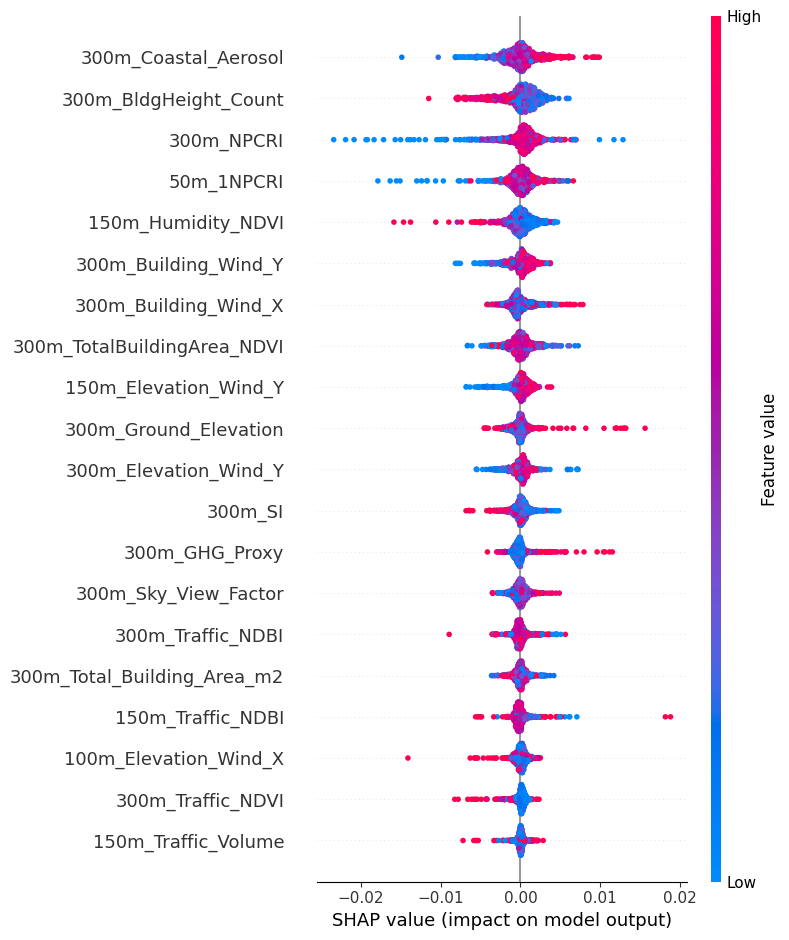

In [8]:
explainer.summary_plot()

>TODO

## Bar Plot

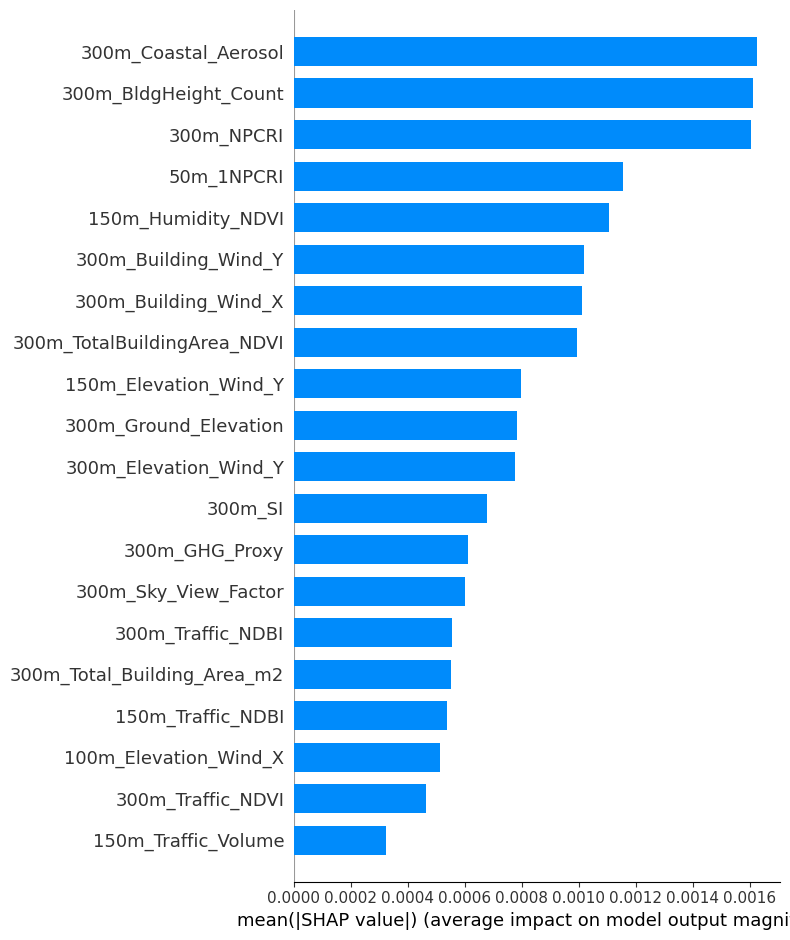

In [9]:
explainer.bar_plot()

>TODO

## Dependence Plot

Here we will create a Dependence Plot for all Important features for us to see the impact on UHI predictions and the interactions with other features.

### 300m Buffer Zone Coastal Aerosol

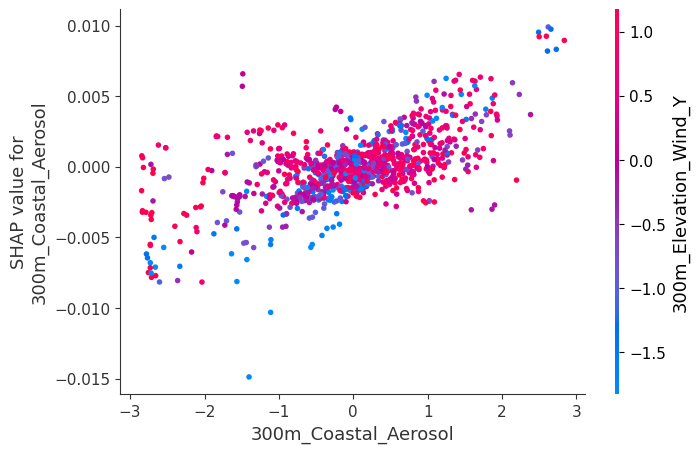

In [10]:
explainer.dependence_plot("300m_Coastal_Aerosol")

>TODO

### Interaction term: 300m Buffer Zone Building Height & Building Count

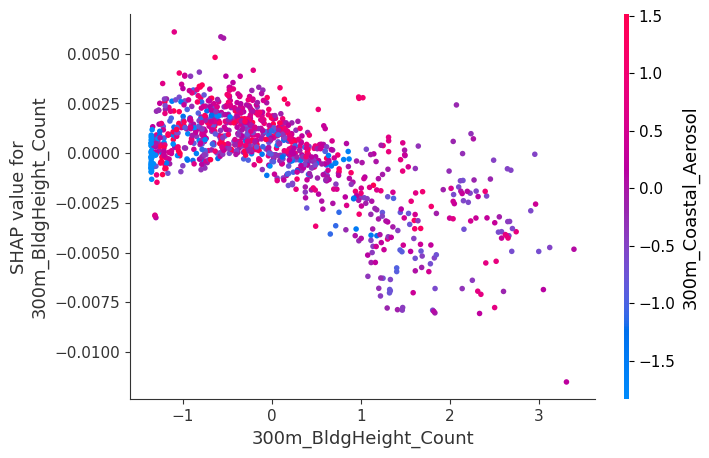

In [11]:
explainer.dependence_plot("300m_BldgHeight_Count")

>TODO

### 300m Buffer Zone NPCRI

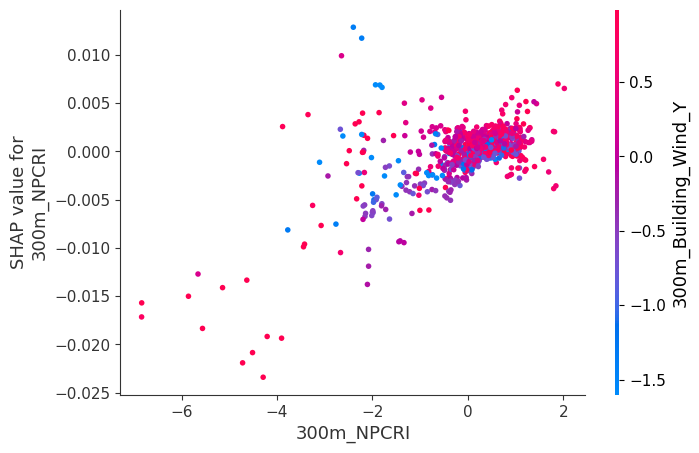

In [12]:
explainer.dependence_plot("300m_NPCRI")

>TODO

### 50m Buffer Zone NPCRI

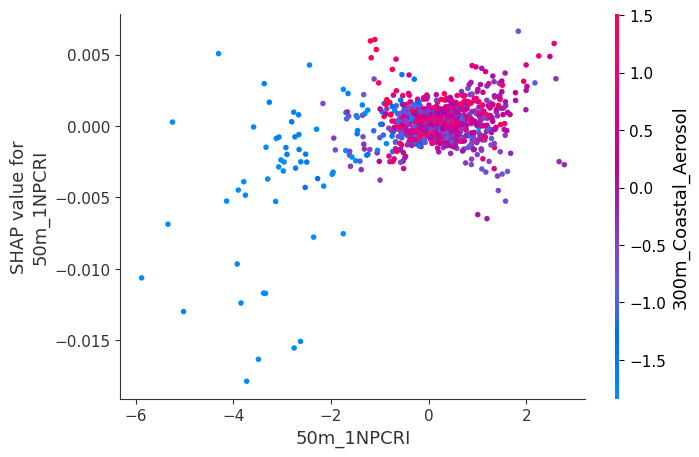

In [13]:
explainer.dependence_plot("50m_1NPCRI")

>TODO

### Interaction term: 150m Buffer Zone Relative Humidity (%) & NDVI

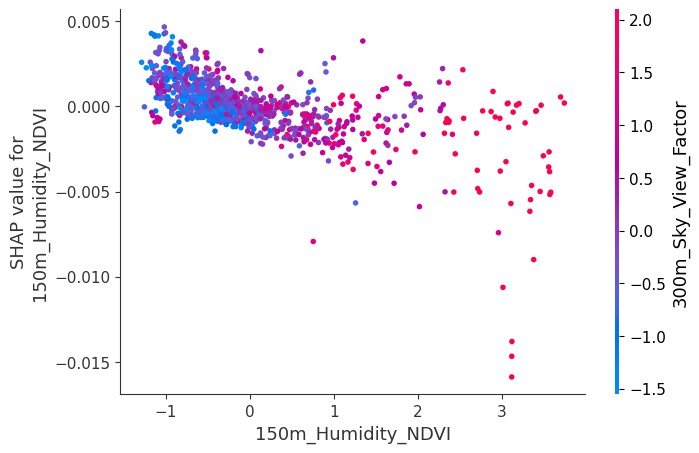

In [14]:
explainer.dependence_plot("150m_Humidity_NDVI")

>TODO

### Interaction term: 300m Buffer Zone Building Height, Avg Wind Speed (m/s), & North-South Wind Component

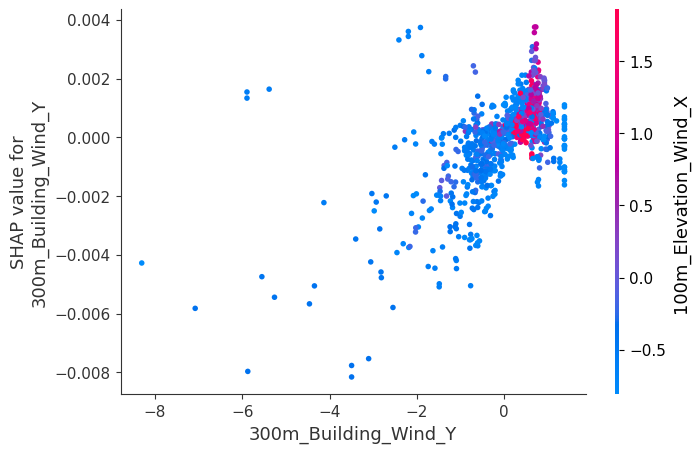

In [15]:
explainer.dependence_plot("300m_Building_Wind_Y")

>TODO

### Interaction term: 300m Buffer Zone Building Height, Avg Wind Speed (m/s), & East-West Wind Component

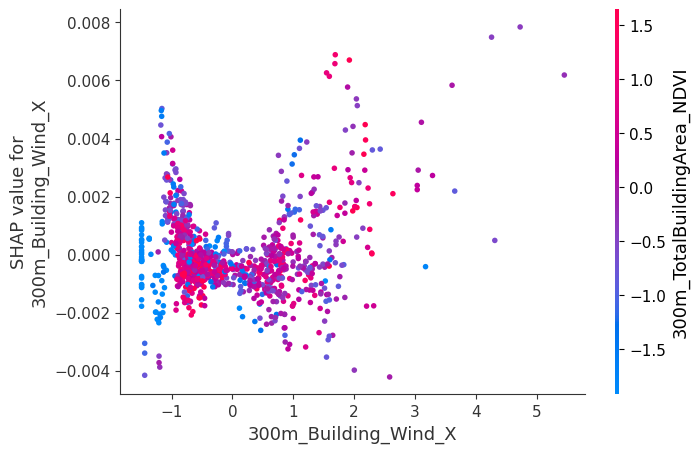

In [16]:
explainer.dependence_plot("300m_Building_Wind_X")

>TODO

### Interaction term: 300m Buffer Zone Total Building Area (m^2) & NDVI

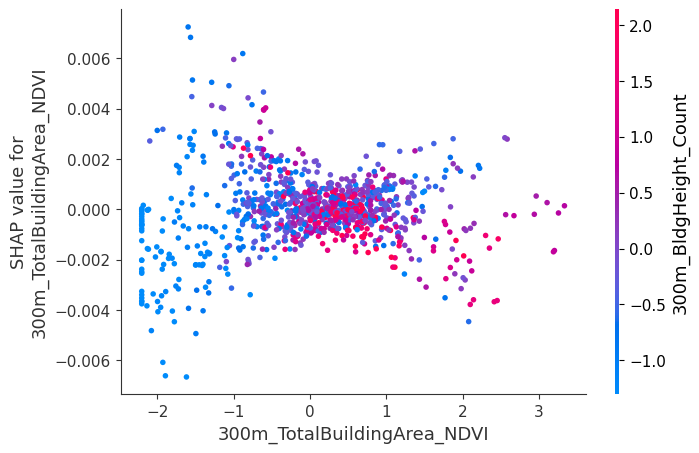

In [17]:
explainer.dependence_plot("300m_TotalBuildingArea_NDVI")

>TODO

### Interaction term: 150m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & North-South Wind Component

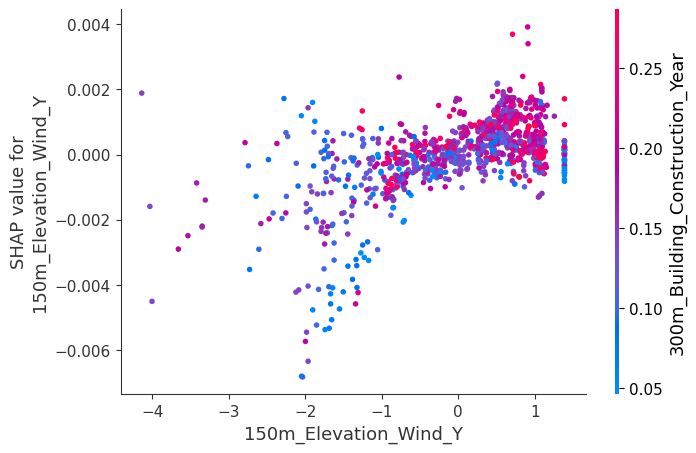

In [18]:
explainer.dependence_plot("150m_Elevation_Wind_Y")

>TODO

### 300m Buffer Zone Ground Elevation

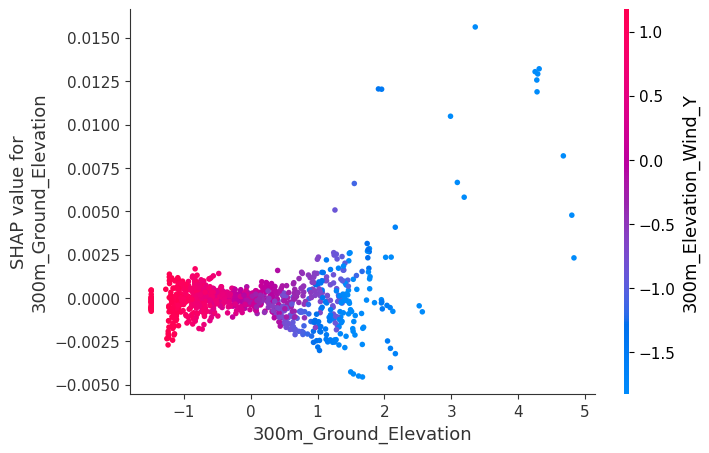

In [19]:
explainer.dependence_plot("300m_Ground_Elevation")

>TODO

### Interaction term: 300m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & North-South Wind Component

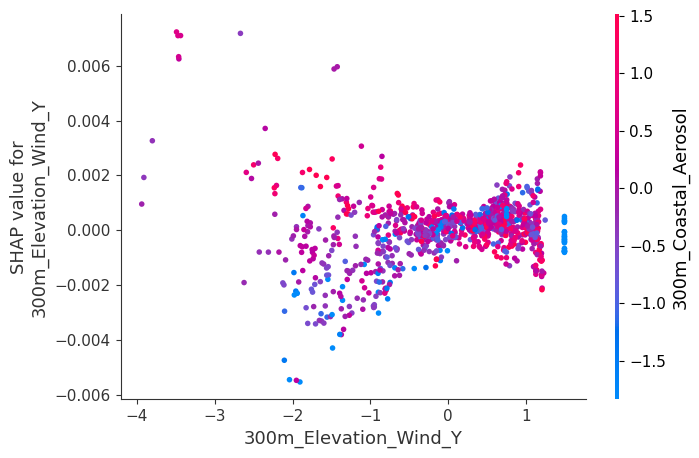

In [20]:
explainer.dependence_plot("300m_Elevation_Wind_Y")

>TODO

### 300m Buffer Zone SI

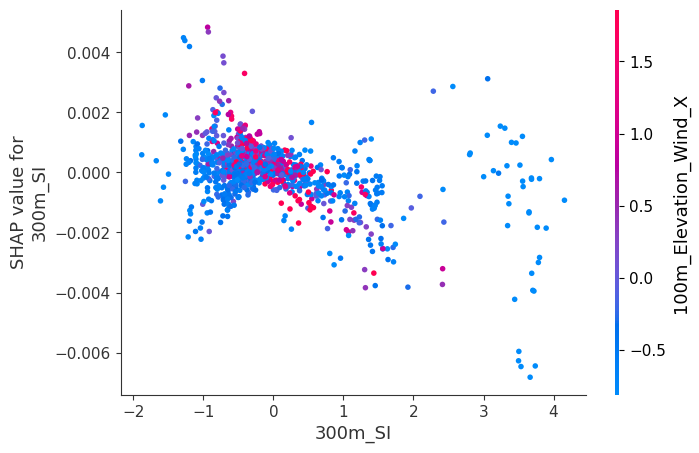

In [21]:
explainer.dependence_plot("300m_SI")

>TODO

### Interaction term: 300m Buffer Zone Building Count, Traffic Volume, & Solar Flux (W/m^2)

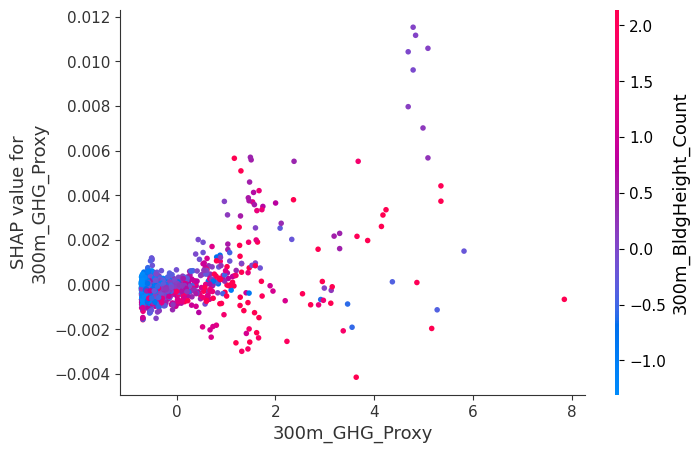

In [22]:
explainer.dependence_plot("300m_GHG_Proxy")

>TODO

### 300m Buffer Zone 1 - Building Density

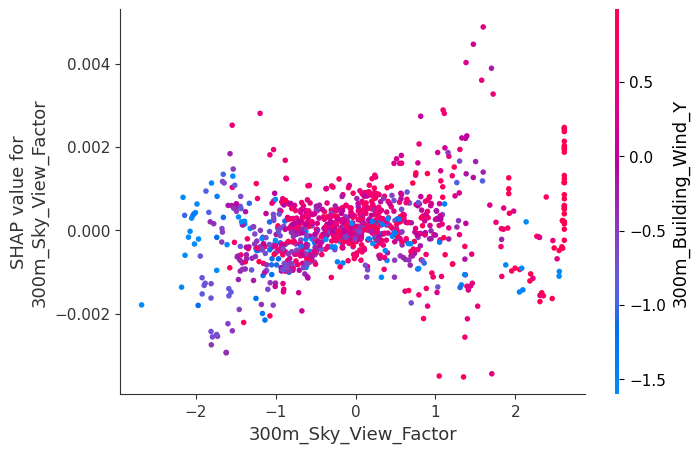

In [23]:
explainer.dependence_plot("300m_Sky_View_Factor")

>TODO

### Interaction term: 300m Buffer Zone Traffic Volume & NDBI

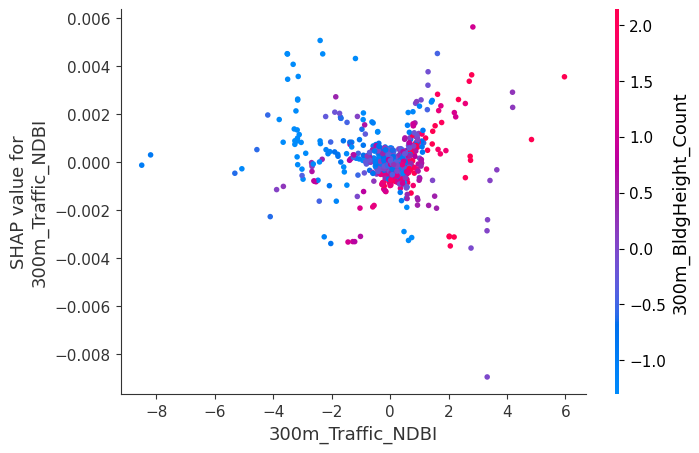

In [24]:
 explainer.dependence_plot("300m_Traffic_NDBI")

>TODO

### 300m Buffer Zone Total Building Area (m^2)

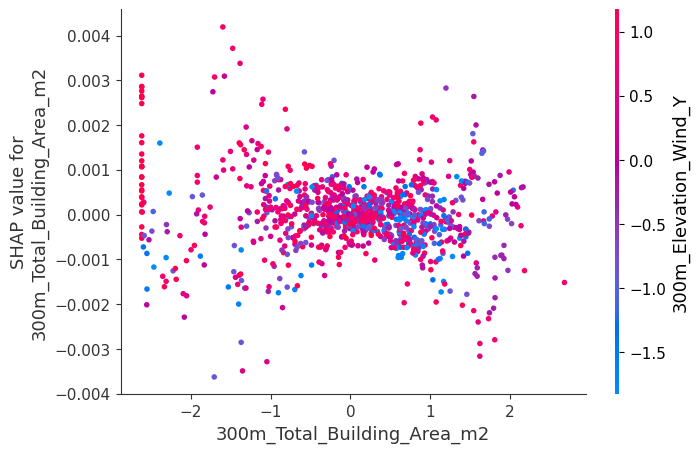

In [25]:
explainer.dependence_plot("300m_Total_Building_Area_m2")

>TODO

### Interaction term: 150m Buffer Zone Traffic Volume & NDBI

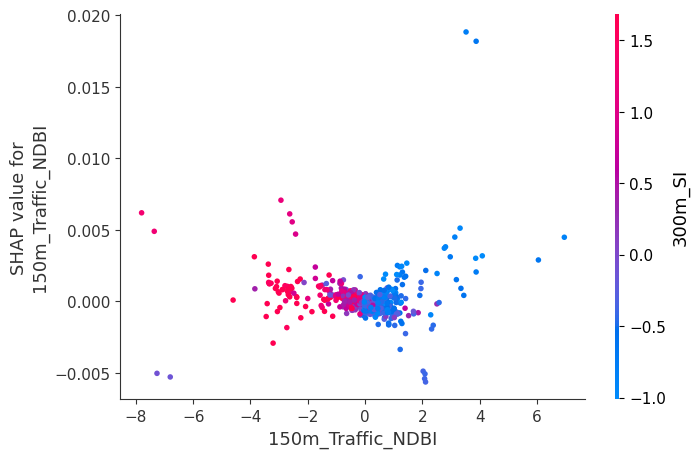

In [26]:
explainer.dependence_plot("150m_Traffic_NDBI")

>TODO

### Interaction term: 100m Buffer Zone Ground Elevation, Avg Wind Speed (m/s), & East-West Wind Component

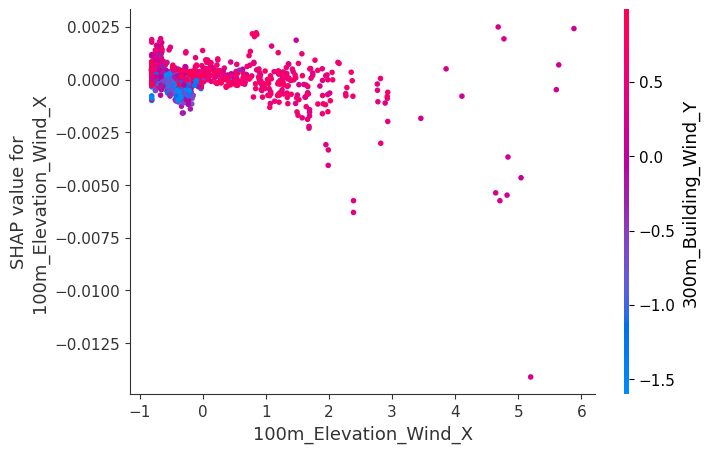

In [27]:
explainer.dependence_plot("100m_Elevation_Wind_X")

>TODO

### Interaction term: 300m Buffer Zone Traffic Volume & NDVI

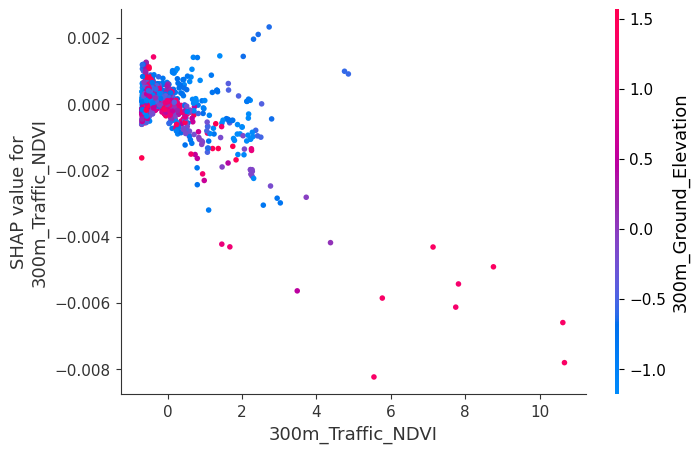

In [28]:
explainer.dependence_plot("300m_Traffic_NDVI")

>TODO

### 150m Traffic Volume

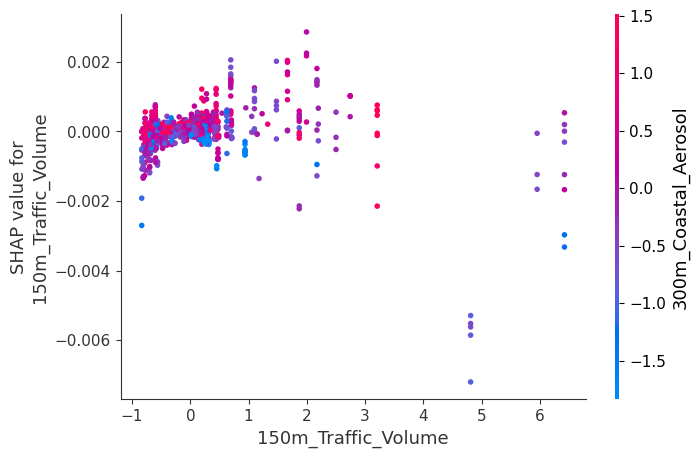

In [29]:
explainer.dependence_plot("150m_Traffic_Volume")

>TODO

## Force Plot

Finally, we will explain an individual prediction within the context of an Urban Heat Island (UHI). Additionally, we will develop a reusable function that allows users to understand why a given prediction receives a high or low UHI Index. This function will provide insights into the specific factors influencing the UHI index for a location, highlighting the key local drivers contributing to the result.

In [30]:
#location index
record_index = 1038

#show location
y_pred[record_index, :]

array([1.0374466], dtype=float32)

In [31]:
shap.initjs()
explainer.force_plot(index=record_index)

>TODO

### Local UHI Explanation Function

>TODO